Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thư mục lưu trữ: /content/drive/MyDrive/ARIMA_Model_SCADA

--- Đang tải và xử lý lại dữ liệu ---
Đang sử dụng 3000 điểm dữ liệu cuối cùng để đảm bảo tính liên tục.
Dữ liệu sạch đưa vào mô hình: 51 dòng
                          Power
timestamp                      
2025-09-24 12:00:00  589.707150
2025-09-24 13:00:00  589.931222
2025-09-24 14:00:00  584.537290
2025-09-24 15:00:00  582.726506
2025-09-24 16:00:00  577.135503

--- Kiểm định tính dừng (ADF Test) ---
ADF Statistic: -3.860910055346685
p-value: 0.002342122862138382

Kích thước tập Train: (40, 1)
Kích thước tập Test: (11, 1)

--- Bắt đầu tìm tham số tối ưu (Auto ARIMA) ---
Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=143.062, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=176.224, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=147.323, Time=0.0

/tmp/ipython-input-3743102967.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = data_recent.resample('H').mean()


 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=144.977, Time=0.11 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=144.885, Time=0.09 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=143.397, Time=0.04 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=146.462, Time=0.03 sec
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=146.715, Time=0.11 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=144.751, Time=0.02 sec

Best model:  ARIMA(1,2,1)(0,0,0)[0] intercept
Total fit time: 0.518 seconds

Mô hình tối ưu tìm được:                                SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   40
Model:               SARIMAX(1, 2, 1)   Log Likelihood                 -67.531
Date:                Mon, 02 Feb 2026   AIC                            143.062
Time:                        01:27:51   BIC                            149.612
Sample:                    09-24-2025   HQIC                           145.392
                         - 09-26-

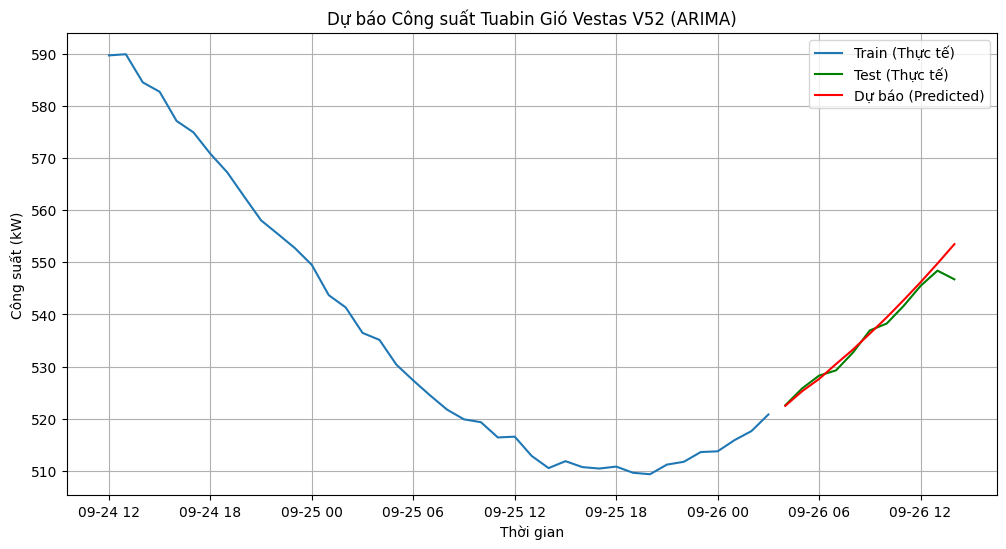

In [ ]:
# BƯỚC 1: CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install pmdarima datasets joblib statsmodels pandas matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from datasets import load_dataset
import joblib
import os
from google.colab import drive


# BƯỚC 2: KẾT NỐI GOOGLE DRIVE ĐỂ LƯU MÔ HÌNH
# Mount Google Drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/ARIMA_Model_SCADA'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Đã tạo thư mục lưu trữ tại: {save_path}")
else:
    print(f"Thư mục lưu trữ: {save_path}")

# BƯỚC 3 (SỬA LẦN CUỐI): CHỈ LẤY DỮ LIỆU LIÊN TỤC
print("\n--- Đang tải và xử lý lại dữ liệu ---")
dataset = load_dataset("vossmoos/vestasv52-scada-windturbine-granada")
df = pd.DataFrame(dataset['train'])

# Chuẩn hóa tên cột
possible_time_cols = ['Timestamp', 'timestamp', 'Date', 'date']
time_col = next((col for col in possible_time_cols if col in df.columns), None)
df.rename(columns={time_col: 'timestamp'}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

# Chọn biến mục tiêu
target_col = 'Active Power' if 'Active Power' in df.columns else 'Power'
data = df[[target_col]].copy()

cutoff_point = -3000
data_recent = data.iloc[cutoff_point:].copy()

print(f"Đang sử dụng {len(data_recent)} điểm dữ liệu cuối cùng để đảm bảo tính liên tục.")

# Xử lý trên tập dữ liệu mới này
data_recent[target_col] = data_recent[target_col].interpolate(method='linear')
data_recent[target_col] = data_recent[target_col].apply(lambda x: 0 if x < 0 else x)

# Tái mẫu về giờ
df_hourly = data_recent.resample('H').mean()
df_hourly = df_hourly.interpolate(method='linear').dropna()

print(f"Dữ liệu sạch đưa vào mô hình: {df_hourly.shape[0]} dòng")
print(df_hourly.head())


# BƯỚC 4: KIỂM ĐỊNH TÍNH DỪNG
print("\n--- Kiểm định tính dừng (ADF Test) ---")
result = adfuller(df_hourly[target_col])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


# BƯỚC 5: CHIA TẬP TRAIN/TEST

# Chia tỷ lệ 80% Train - 20% Test theo trình tự thời gian
train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

print(f"\nKích thước tập Train: {train.shape}")
print(f"Kích thước tập Test: {test.shape}")

# BƯỚC 6: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH

print("\n--- Bắt đầu tìm tham số tối ưu (Auto ARIMA) ---")

model = auto_arima(train[target_col],
                   start_p=1, start_q=1,
                   max_p=5, max_q=5,
                   m=1,
                   d=None,
                   seasonal=False,
                   stepwise=True,
                   trace=True,
                   error_action='ignore',
                   suppress_warnings=True)

print(f"\nMô hình tối ưu tìm được: {model.summary()}")


# BƯỚC 7: LƯU MÔ HÌNH VÀO MYDRIVE
model_filename = f'{save_path}/best_arima_model.pkl'
joblib.dump(model, model_filename)
print(f"\nĐã lưu mô hình thành công tại: {model_filename}")

# BƯỚC 8: DỰ BÁO KIỂM THỬ

print("\n--- Dự báo trên tập Test ---")
prediction, conf_int = model.predict(n_periods=len(test), return_conf_int=True)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
plt.plot(train.index, train[target_col], label='Train (Thực tế)')
plt.plot(test.index, test[target_col], label='Test (Thực tế)', color='green')
plt.plot(test.index, prediction, label='Dự báo (Predicted)', color='red')
plt.title('Dự báo Công suất Tuabin Gió Vestas V52 (ARIMA)')
plt.xlabel('Thời gian')
plt.ylabel('Công suất (kW)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chuẩn bị dữ liệu
# y_true: Giá trị thực tế (từ tập Test)
# y_pred: Giá trị dự báo (từ biến prediction)
y_true = test[target_col]
y_pred = prediction

# 2. Tính toán các chỉ số
# MAE: Sai số tuyệt đối trung bình
mae = mean_absolute_error(y_true, y_pred)

# RMSE: Căn bậc hai của sai số bình phương trung bình
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# MAPE: Sai số phần trăm trung bình tuyệt đối
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

# 3. In kết quả
print("-" * 30)
print("KẾT QUẢ ĐÁNH GIÁ SAI SỐ DỰ BÁO")
print("-" * 30)
print(f"1. MAE (Mean Absolute Error):   {mae:.4f} kW")
print(f"2. RMSE (Root Mean Sq. Error):  {rmse:.4f} kW")
print(f"3. MAPE (Mean Abs. % Error):    {mape:.4f} %")
print("-" * 30)

# Đánh giá sơ bộ
print("\nNHẬN XÉT NHANH:")
if mape < 10:
    print("-> Mô hình dự báo RẤT TỐT (Sai số dưới 10%)")
elif mape < 20:
    print("-> Mô hình dự báo KHÁ (Sai số từ 10-20%)")
else:
    print("-> Cần cải thiện thêm (Sai số trên 20%)")

------------------------------
KẾT QUẢ ĐÁNH GIÁ SAI SỐ DỰ BÁO
------------------------------
1. MAE (Mean Absolute Error):   1.3460 kW
2. RMSE (Root Mean Sq. Error):  2.2042 kW
3. MAPE (Mean Abs. % Error):    0.2485 %
------------------------------

NHẬN XÉT NHANH:
-> Mô hình dự báo RẤT TỐT (Sai số dưới 10%)


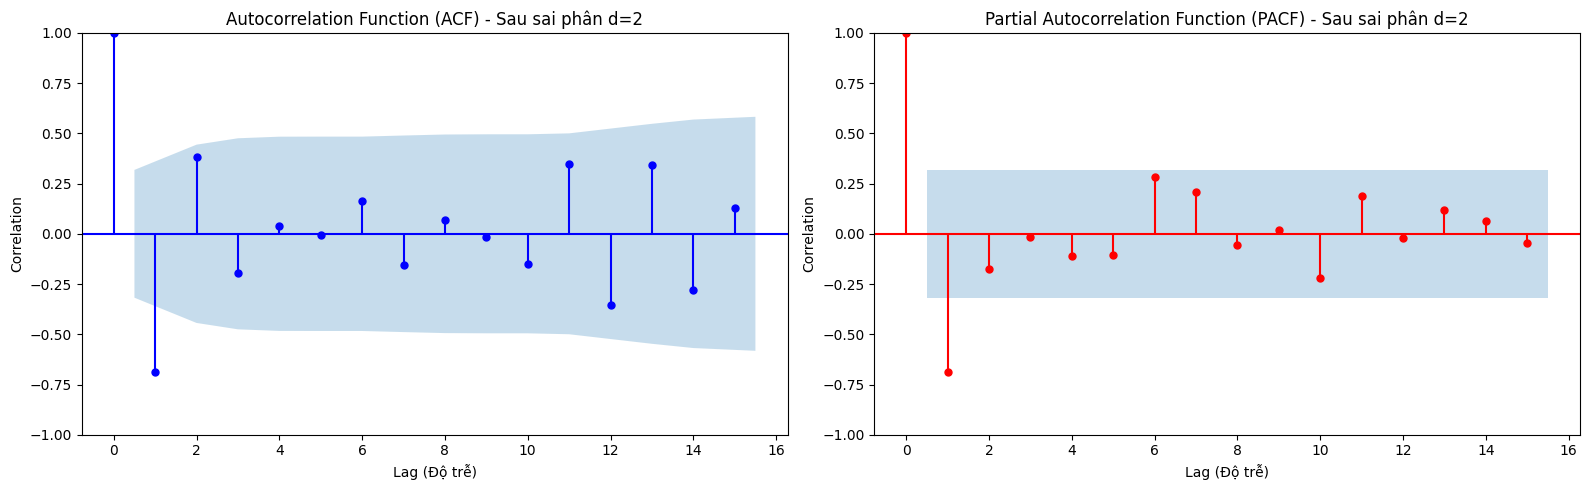

-> Đã lưu Hình 4.1


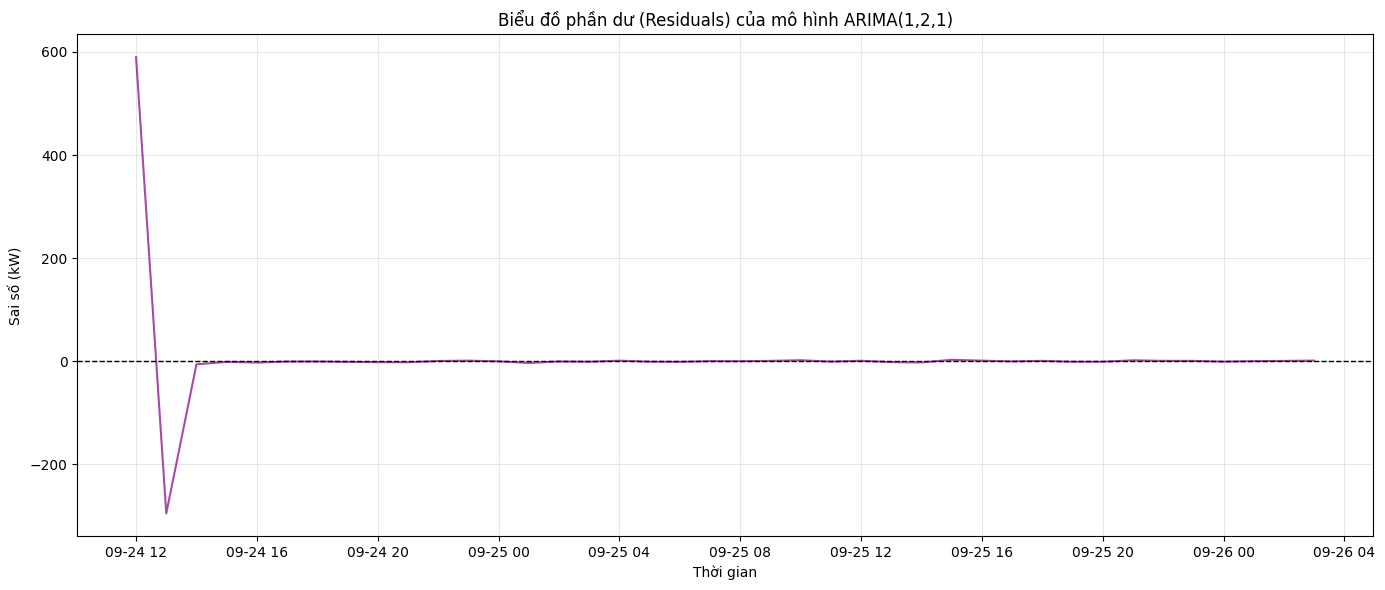

-> Đã lưu Hình 4.2


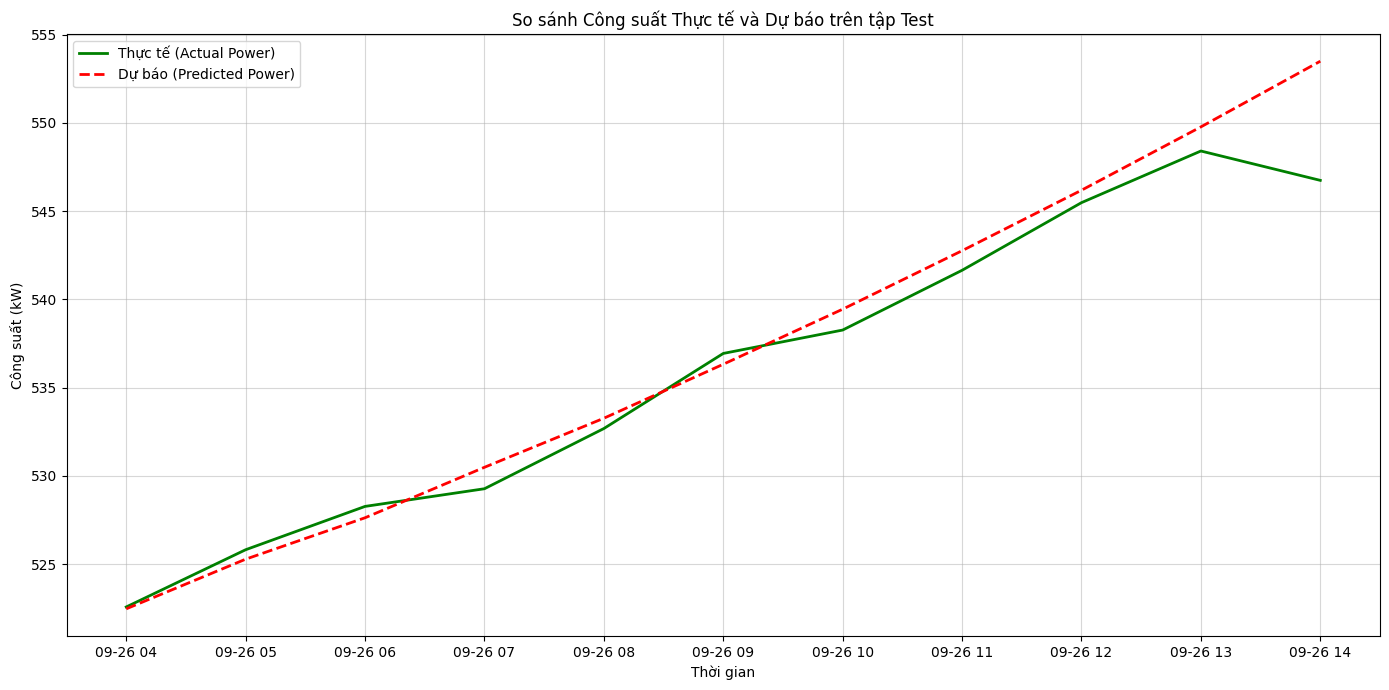

-> Đã lưu Hình 4.3


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import pandas as pd

save_dir = '/content/drive/MyDrive/ARIMA_Model_SCADA'

# HÌNH 4.1: Đồ thị ACF và PACF (Của chuỗi đã lấy sai phân d=2)
# Lấy chuỗi sai phân bậc 2 từ tập TRAIN
diff_series = train[target_col].diff().diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
safe_lags = 15

# Vẽ ACF
plot_acf(diff_series, ax=ax1, lags=safe_lags, color='blue', vlines_kwargs={"colors": "blue"})
ax1.set_title('Autocorrelation Function (ACF) - Sau sai phân d=2')
ax1.set_xlabel('Lag (Độ trễ)')
ax1.set_ylabel('Correlation')

# Vẽ PACF
plot_pacf(diff_series, ax=ax2, lags=safe_lags, color='red', vlines_kwargs={"colors": "red"}, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF) - Sau sai phân d=2')
ax2.set_xlabel('Lag (Độ trễ)')
ax2.set_ylabel('Correlation')

plt.tight_layout()
plt.savefig(f'{save_dir}/Hinh_4.1_ACF_PACF.png', dpi=300)
plt.show()
print("-> Đã lưu Hình 4.1")

# HÌNH 4.2: Biểu đồ phần dư (Residuals)
residuals = model.resid()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(residuals.index, residuals, color='purple', alpha=0.7)
ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_title('Biểu đồ phần dư (Residuals) của mô hình ARIMA(1,2,1)')
ax.set_ylabel('Sai số (kW)')
ax.set_xlabel('Thời gian')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{save_dir}/Hinh_4.2_Residuals.png', dpi=300)
plt.show()
print("-> Đã lưu Hình 4.2")

fig, ax = plt.subplots(figsize=(14, 7))

# Vẽ dữ liệu thực tế (Test)
ax.plot(test.index, test[target_col], label='Thực tế (Actual Power)', color='green', linewidth=2)

# Vẽ dữ liệu dự báo (Predicted)
# Đảm bảo prediction có cùng index với test để vẽ đúng
pred_series = pd.Series(prediction, index=test.index)
ax.plot(pred_series.index, pred_series, label='Dự báo (Predicted Power)', color='red', linestyle='--', linewidth=2)

ax.set_title('So sánh Công suất Thực tế và Dự báo trên tập Test')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Công suất (kW)')
ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{save_dir}/Hinh_4.3_Actual_vs_Predicted.png', dpi=300)
plt.show()
print("-> Đã lưu Hình 4.3")